# Regenerate plots from Richardson and Korotkin 2021 for Q = I($U(c_{s,avg})$-$U(c_{s,surf})$)

In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [2]:
chemistry = pybamm.parameter_sets.Ecker2015
param = pybamm.ParameterValues(chemistry)
param.update({
    'Tabbing resistance [Ohm]':0,
    'Initial fraction of Li in SEI': 0.15,
}, check_already_exists = False)
option = {
    "thermal": "x-lumped",
}

model = pybamm.lithium_ion.DFN(options = option)

experiment = pybamm.Experiment(
    ["Discharge at 5 C for 12 minutes or until 0 V",
    # "Rest for 5 minutes",
    ]

)

solver = pybamm.CasadiSolver(mode="safe") #, extra_options_setup={"max_num_steps": 10000}
sim = pybamm.Simulation(model, experiment=experiment, parameter_values = param, solver= solver)
solution = sim.solve( initial_soc=1)


In [3]:
model.variables.search('radius')

Negative particle radius
Negative particle radius [m]
Positive particle radius
Positive particle radius [m]


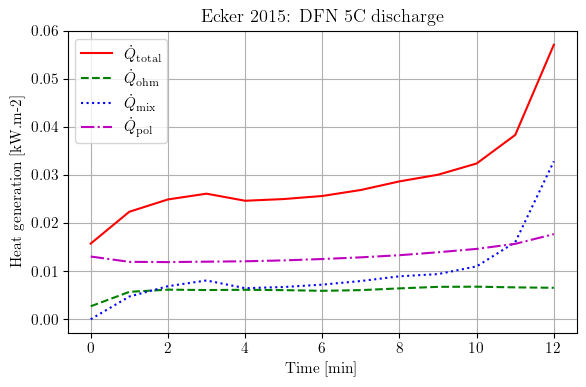

In [7]:
L_x = param.evaluate(pybamm.geometric_parameters.L_x)
L_xn = param.evaluate(pybamm.geometric_parameters.n.L)
L_y = param.evaluate(pybamm.geometric_parameters.L_y)
L_z = param.evaluate(pybamm.geometric_parameters.L_z)
L = param.evaluate(pybamm.geometric_parameters.L)
Vx = L_x*L_y*L_z
V = L*L_y*L_z

scalar = L/1000
t = solution["Time [s]"].entries/60
Q_total = (solution['Volume-averaged total heating [W.m-3]'].entries)*scalar
Q_sei = solution['SEI decomposition heating [W.m-3]'].entries*L # should be anode not cell volume?
Q_rxn = (solution['Volume-averaged irreversible electrochemical heating [W.m-3]'].entries)*scalar
Q_ohm = solution['Volume-averaged Ohmic heating [W.m-3]'].entries*scalar #- Q_tabbing  
Q_part = solution['Volume-averaged heat of mixing [W.m-3]'].entries*scalar

fig, ax = plt.subplots(1,  1, figsize=(6, 4), sharex=True, constrained_layout=True)#, constrained_layout=True
sim_colors = ['r', 'b', 'limegreen','darkorange']
ax.plot(t, Q_total, color = 'r', linestyle = '-', label = '$\dot{Q}_\mathrm{{total}}$')
ax.plot(t, Q_ohm, color = 'g', linestyle = '--', label = '$\dot{Q}_\mathrm{{ohm}}$')
ax.plot(t, Q_part, color = 'b', linestyle = ':', label = '$\dot{Q}_\mathrm{{mix}}$')
ax.plot(t, Q_rxn, color = 'm', linestyle = '-.', label = '$\dot{Q}_\mathrm{{pol}}$')
# ax.plot(t, Q_sei, color = sim_colors[3], linestyle = '--', label = '$\dot{Q}_\mathrm{{SEI}}$')


# ax.set_ylim([0,700])
ax.set_xlabel('Time [min]')
ax.set_ylabel('Heat generation [kW.m-2]')
ax.grid('on')
ax.legend(loc = 'upper left')
# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', ncol=4, prop={'size': 10},  bbox_to_anchor=(0.5, 1.0))
# plt.legend(loc = 'upper right')
ax.set_title('Ecker 2015: DFN 5C discharge')
plt.tight_layout()
plt.show()

In [5]:
# r = solution['Negative particle radius [m]'].entries
# solution['Negative particle concentration'](r = r[0], x=0.0001, t=0.1)
# cs = solution['Negative particle concentration'](r = r[0], x=0.0001, t=0.1)
# param['Negative electrode OCP [V]'](cs)
# Un =  param.evaluate(pybamm.lithium_ion.param.n.prim.U)

In [6]:
%matplotlib inline
# quick_plot = pybamm.QuickPlot(solution)
# quick_plot.dynamic_plot(variables = {'Negative particle concentration'})

pybamm.dynamic_plot(
    solution,
    [
     'Negative particle concentration',
     'Negative electrode open circuit potential'
    ],
)

interactive(children=(FloatSlider(value=0.0, description='t', max=720.0, step=7.2), Output()), _dom_classes=('…